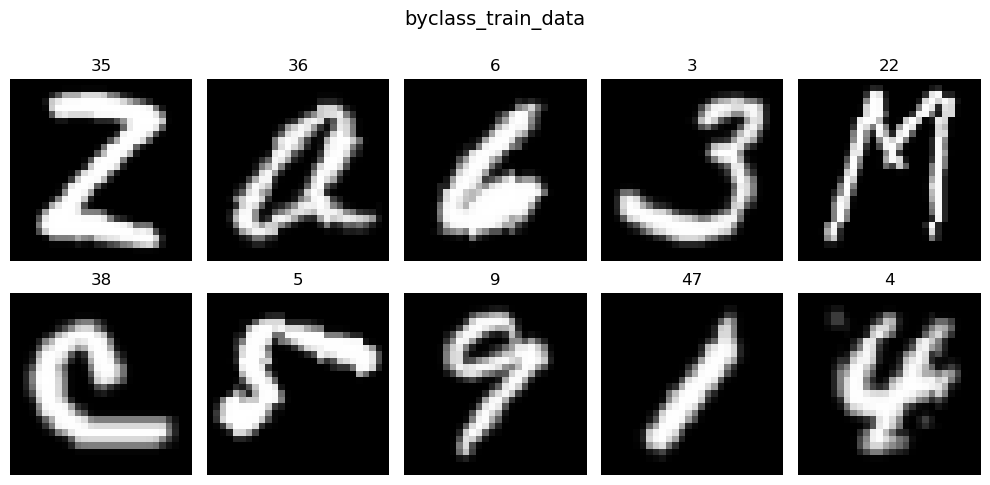

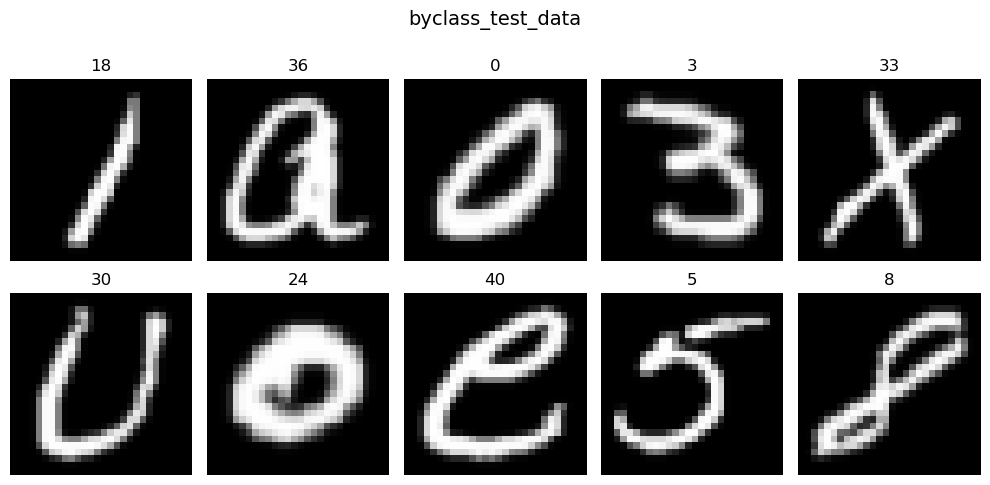

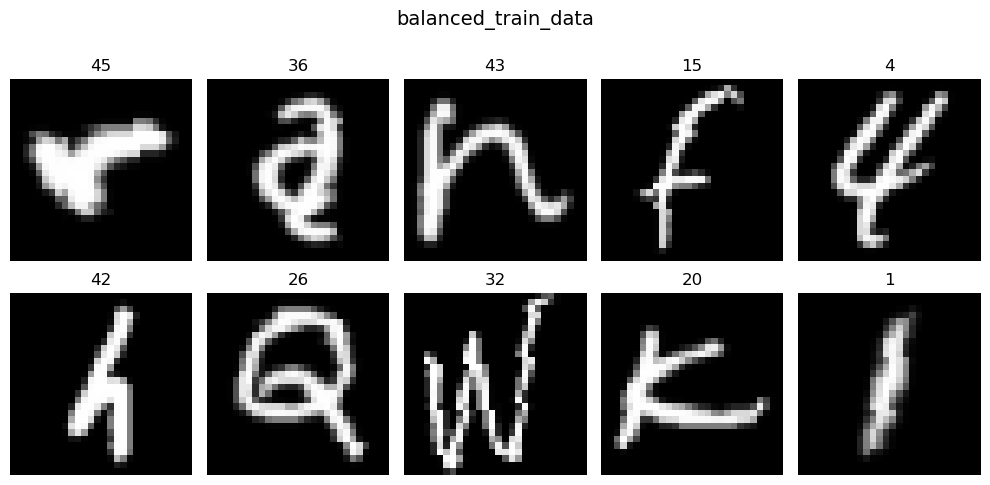

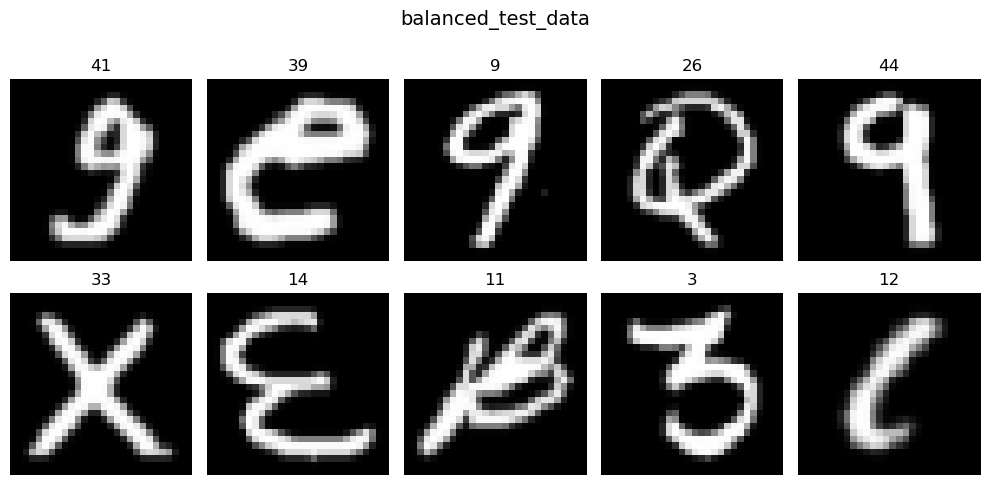

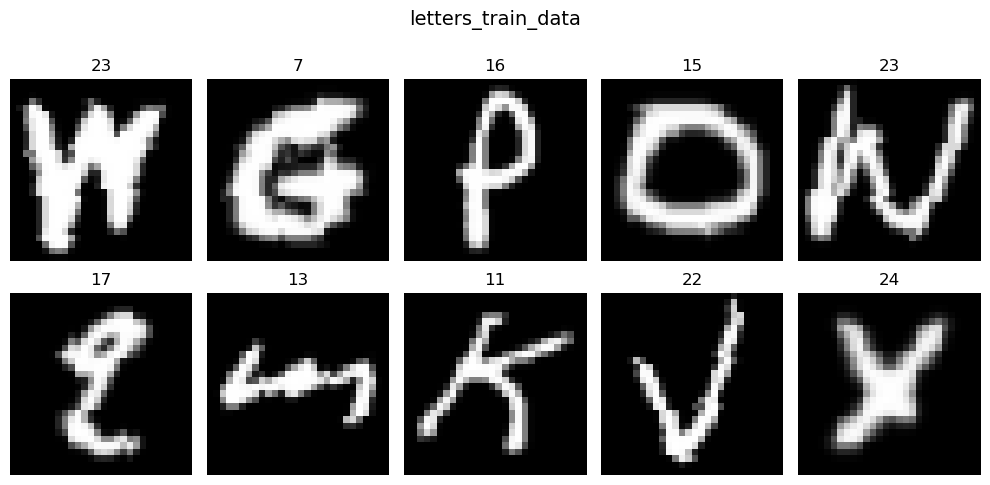

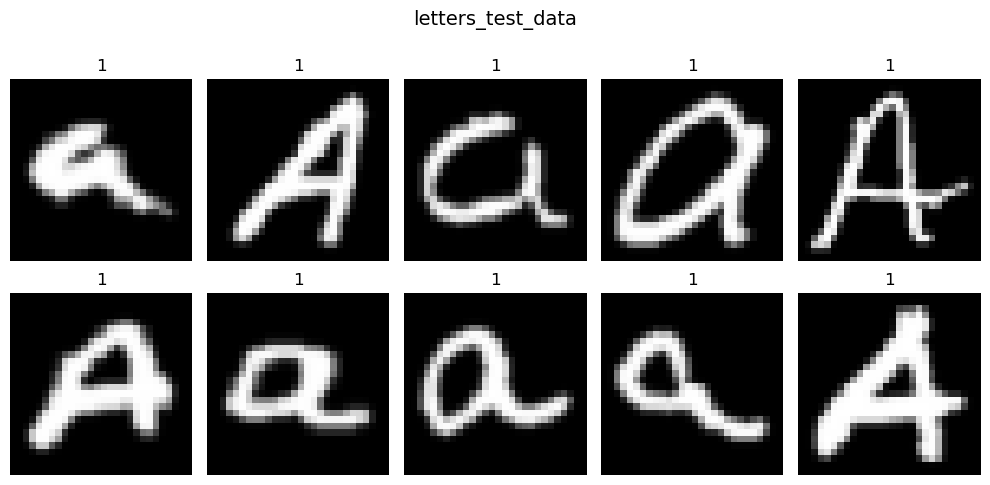

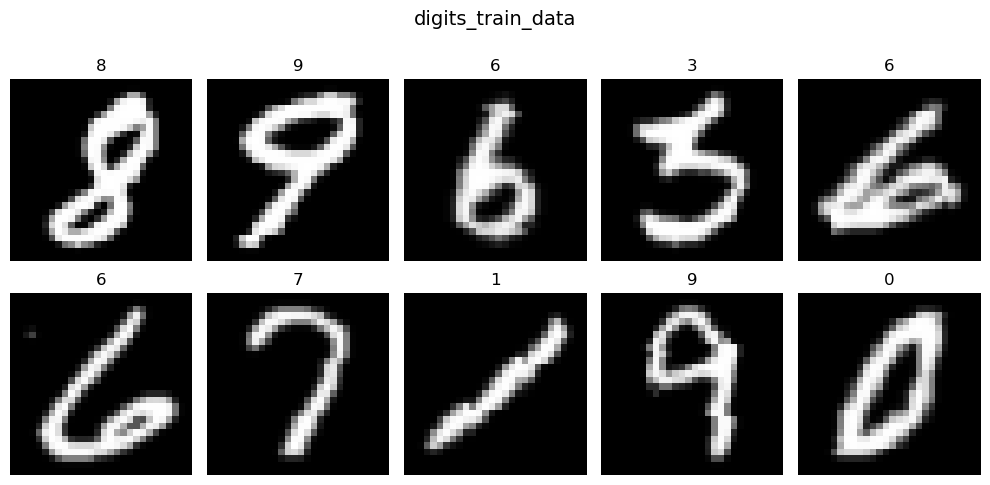

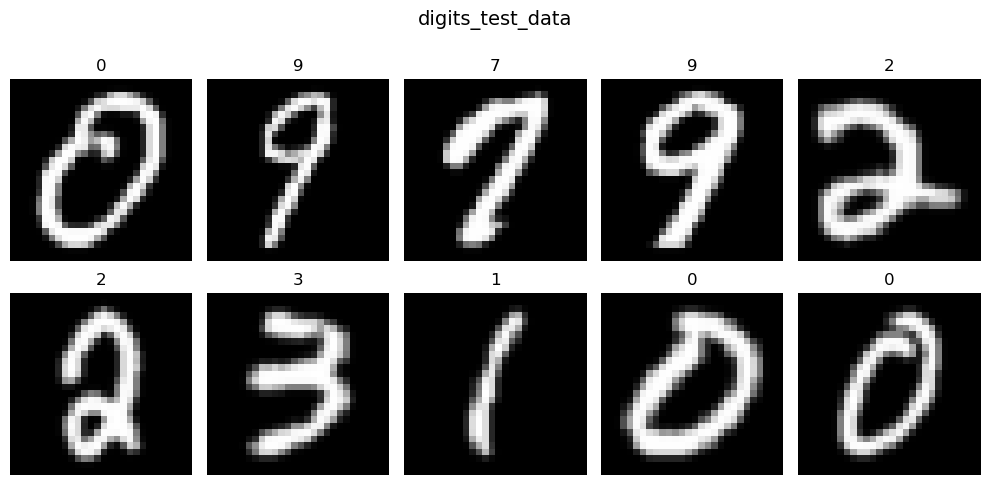

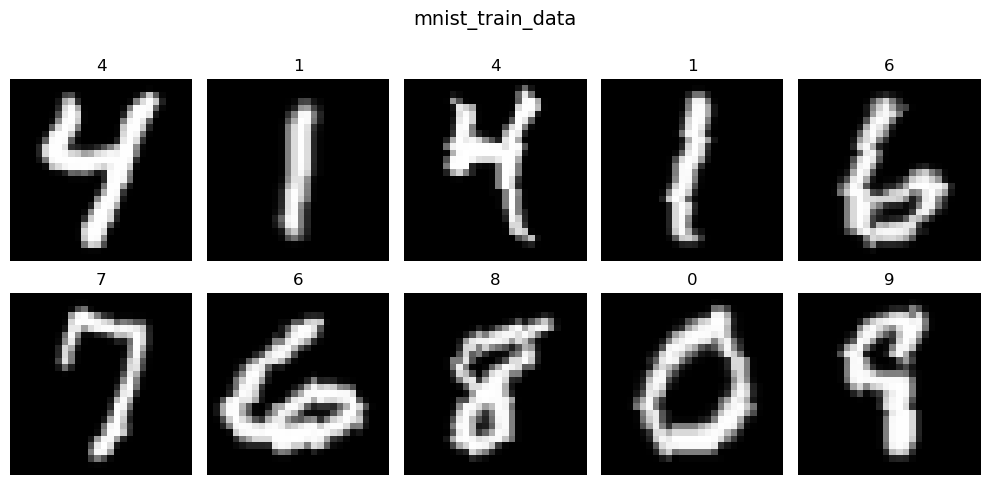

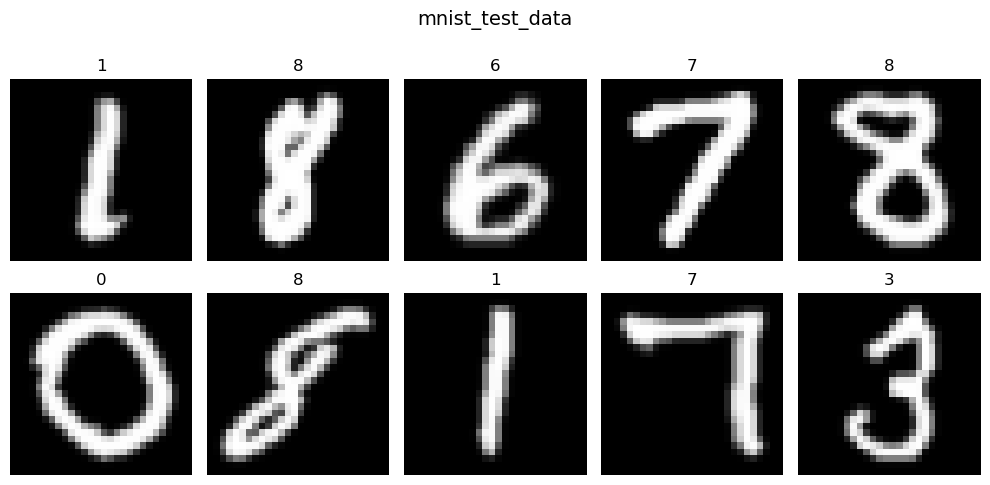

In [1]:
import torch
from torchvision.datasets import EMNIST
from torchvision.transforms import v2

'''

tran = v2.Compose([v2.RandomHorizontalFlip(p=1.0),
                   v2.RandomRotation(degrees=(90, 90))])

'''

# ✅ Recommandé : correction + normalisation + augmentation légère
tran_train = v2.Compose([
    v2.RandomHorizontalFlip(p=1.0),          # correction EMNIST
    v2.RandomRotation(degrees=(90, 90)),      # correction EMNIST
    v2.RandomRotation(degrees=(-10, 10)),     # augmentation légère
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),    # [0, 1]
    v2.Normalize(mean=[0.1307], std=[0.3081]) # normalisation MNIST/EMNIST
])

tran_test = v2.Compose([
    v2.RandomHorizontalFlip(p=1.0),
    v2.RandomRotation(degrees=(90, 90)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.1307], std=[0.3081])
])

byclass_train_data = EMNIST(
    root="data",
    split="byclass",
    train=True,
    transform=tran_train
)

byclass_test_data = EMNIST(
    root="data",
    split="byclass",
    train=False,
    transform=tran_test
)

balanced_train_data = EMNIST(
    root="data",
    split="balanced",
    train=True,
    transform=tran_train
)

balanced_test_data = EMNIST(
    root="data",
    split="balanced",
    train=False,
    transform=tran_test
)

letters_train_data = EMNIST(
    root="data",
    split="letters",
    train=True,
    transform=tran_train
)

letters_test_data = EMNIST(
    root="data",
    split="letters",
    train=False,
    transform=tran_test
)

digits_train_data = EMNIST(
    root="data",
    split="digits",
    train=True,
    transform=tran_train
)

digits_test_data = EMNIST(
    root="data",
    split="digits",
    train=False,
    transform=tran_test
)

mnist_train_data = EMNIST(
    root="data",
    split="mnist",
    train=True,
    transform=tran_train
)

mnist_test_data = EMNIST(
    root="data",
    split="mnist",
    train=False,
    transform=tran_test
)

import matplotlib.pyplot as plt

def show_images(data, main_title=None):
    plt.figure(figsize=(10, 5))
    plt.suptitle(t=main_title, y=1.0, fontsize=14)
    for i, (im, lab) in zip(range(1, 11), data):
        plt.subplot(2, 5, i)
        # (1, 28, 28) → (28, 28, 1) puis squeeze → (28, 28)
        plt.imshow(X=im.permute(1, 2, 0).squeeze(), cmap="gray")
        plt.title(label=lab)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
    
'''

def show_images(data, main_title=None):
    plt.figure(figsize=(10, 5))
    plt.suptitle(t=main_title, y=1.0, fontsize=14)
    for i, (im, lab) in zip(range(1, 11), data):
        plt.subplot(2, 5, i)
        plt.imshow(X=im)
        plt.title(label=lab)
    plt.tight_layout()
    plt.show()

'''
show_images(data=byclass_train_data, main_title="byclass_train_data")
show_images(data=byclass_test_data, main_title="byclass_test_data")

show_images(data=balanced_train_data, main_title="balanced_train_data")
show_images(data=balanced_test_data, main_title="balanced_test_data")

show_images(data=letters_train_data, main_title="letters_train_data")
show_images(data=letters_test_data, main_title="letters_test_data")

show_images(data=digits_train_data, main_title="digits_train_data")
show_images(data=digits_test_data, main_title="digits_test_data")

show_images(data=mnist_train_data, main_title="mnist_train_data")
show_images(data=mnist_test_data, main_title="mnist_test_data")

In [2]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    byclass_train_data,
    batch_size=64,
    shuffle=True,
    num_workers=4
)

test_loader = DataLoader(
    byclass_test_data,
    batch_size=64,
    shuffle=False,
    num_workers=4
)

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Create a simple neural net
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 62)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


# 3. Train the neural network
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")

# Test the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

print(f"Accuracy on test set: {100 * correct / total:.2f}%")

# Save the model
torch.save(model.state_dict(), "mnist_model.pth")


Epoch 1/5, Batch 0/10906, Loss: 4.2424
Epoch 1/5, Batch 100/10906, Loss: 1.5315
Epoch 1/5, Batch 200/10906, Loss: 1.2361
Epoch 1/5, Batch 300/10906, Loss: 1.2459
Epoch 1/5, Batch 400/10906, Loss: 1.0516
Epoch 1/5, Batch 500/10906, Loss: 1.3372
Epoch 1/5, Batch 600/10906, Loss: 1.1621
Epoch 1/5, Batch 700/10906, Loss: 1.3747
Epoch 1/5, Batch 800/10906, Loss: 0.8909
Epoch 1/5, Batch 900/10906, Loss: 0.5980
Epoch 1/5, Batch 1000/10906, Loss: 0.9427
Epoch 1/5, Batch 1100/10906, Loss: 0.8082
Epoch 1/5, Batch 1200/10906, Loss: 0.7086
Epoch 1/5, Batch 1300/10906, Loss: 1.2477
Epoch 1/5, Batch 1400/10906, Loss: 1.0221
Epoch 1/5, Batch 1500/10906, Loss: 0.5937
Epoch 1/5, Batch 1600/10906, Loss: 0.7021
Epoch 1/5, Batch 1700/10906, Loss: 0.7125
Epoch 1/5, Batch 1800/10906, Loss: 0.8537
Epoch 1/5, Batch 1900/10906, Loss: 0.8750
Epoch 1/5, Batch 2000/10906, Loss: 0.6825
Epoch 1/5, Batch 2100/10906, Loss: 0.6556
Epoch 1/5, Batch 2200/10906, Loss: 0.7680
Epoch 1/5, Batch 2300/10906, Loss: 0.8308
Epoc